# Lab 3: Simple Linear Regression

In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pickle
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Setting style for better plots
sns.set_style("whitegrid")
plt.rcParams.update({'font.size': 12, 'axes.titlesize': 14, 'axes.labelsize': 12})

In [11]:
# Loading the student survey dataset
df = pd.read_csv("Student Awareness Survey (Responses) - Form Responses 1.csv")
print(f"Dataset loaded successfully: {df.shape[0]} rows, {df.shape[1]} columns")

Dataset loaded successfully: 50 rows, 15 columns


## Task 1: Dataset Audit

### Dataset Structure

In [12]:
print("=" * 60)
print("DATASET STRUCTURE")
print("=" * 60)
print(f"\nShape: {df.shape[0]} rows x {df.shape[1]} columns")
print(f"\nColumn names: {list(df.columns)}")
print(f"\nData types:\n{df.dtypes}")

DATASET STRUCTURE

Shape: 50 rows x 15 columns

Column names: ['Timestamp', 'Registration Number', 'Email', 'Job role that you are interested in', 'What is the minimum salary of students placed through campus (In LPA..respond as a number)', 'What is the maximum salary of students placed through campus (In LPA..respond as a number)', 'What is the median salary of students placed through campus (In LPA..respond as a number)', 'Which is the highest paying company that recruits from campus?', 'Rate your contribution towards extra curricular activities', 'Rate your technical competencies', 'What are your package expectations (LPA)', 'Your CIA % of last semester', 'Your GPA of last semester', 'Your maximum attendance % till last semester', 'Internships Interests']

Data types:
Timestamp                                                                                      object
Registration Number                                                                             int64
Email         

### Data Quality Assessment

In [13]:
print("\n" + "=" * 60)
print("MISSING VALUES ANALYSIS")
print("=" * 60)
missing = df.isnull().sum()
print(missing[missing > 0] if missing.sum() > 0 else "No missing values detected")

print("\n" + "=" * 60)
print("DUPLICATE ROWS")
print("=" * 60)
duplicates = df.duplicated().sum()
print(f"Duplicate rows: {duplicates}")


MISSING VALUES ANALYSIS
Which is the highest paying company that recruits from campus?    1
Rate your contribution towards extra curricular activities        1
Rate your technical competencies                                  1
What are your package expectations (LPA)                          1
Internships Interests                                             1
dtype: int64

DUPLICATE ROWS
Duplicate rows: 0


### Variable Descriptions for Regression Analysis

The following columns are relevant for our regression analysis:
- **Your CIA % of last semester**: Continuous Internal Assessment percentage (independent variable)
- **Your GPA of last semester**: Grade Point Average (dependent variable/target)
- **Your maximum attendance % till last semester**: Attendance percentage (independent variable)

## Task 1: Dataset Audit Observations

**Dataset Structure:**
- 50 student responses with 15 columns
- Contains both numerical and categorical data
- Key columns for regression: CIA %, GPA, Attendance %

**Data Quality Issues Identified:**
- Inconsistent formatting in numerical columns (e.g., "71 %", "85%", "3.5 LPA")
- Some entries have text mixed with numbers (e.g., "8-9", "3+ lpa", "13++lpa")
- Missing values in some columns (e.g., highest paying company)
- No duplicate rows detected

**Critical Observation:** The dataset requires significant preprocessing before regression analysis due to inconsistent data entry formats in the key numerical columns.

## Task 2: Data Preprocessing

### Extracting and Cleaning Key Variables

In [14]:
# Extract relevant columns
cia_col = 'Your CIA % of last semester'
gpa_col = 'Your GPA of last semester'
attendance_col = 'Your maximum attendance % till last semester'

# Create a clean DataFrame with only the columns we need
df_clean = df[[cia_col, gpa_col, attendance_col]].copy()
df_clean.columns = ['CIA', 'GPA', 'Attendance']

print("Original data sample:")
print(df_clean.head(10))

Original data sample:
  CIA   GPA Attendance
0  69  3.40         98
1  75  3.69         95
2  82  3.41         95
3  91  3.60         92
4  70  3.54         93
5  75  3.67         98
6  74  3.40         94
7  68  3.40         85
8  73  3.60         90
9  79  3.73         93


In [15]:
# Function to clean percentage and numerical values
def clean_numeric(value):
    """Convert various string formats to numeric values."""
    if pd.isna(value):
        return np.nan
    
    # Convert to string and clean
    value_str = str(value).strip()
    
    # Remove percentage signs, LPA, and other text
    value_str = value_str.replace('%', '').replace('LPA', '').replace('lpa', '').strip()
    
    # Handle range values (take the average)
    if '-' in value_str or '+' in value_str:
        # For simplicity, extract the first number
        import re
        numbers = re.findall(r'\d+\.?\d*', value_str)
        if numbers:
            return float(numbers[0])
        return np.nan
    
    # Convert to float
    try:
        return float(value_str)
    except:
        return np.nan

# Apply cleaning to all columns
df_clean['CIA'] = df_clean['CIA'].apply(clean_numeric)
df_clean['GPA'] = df_clean['GPA'].apply(clean_numeric)
df_clean['Attendance'] = df_clean['Attendance'].apply(clean_numeric)

print("\nCleaned data sample:")
print(df_clean.head(10))


Cleaned data sample:
    CIA   GPA  Attendance
0  69.0  3.40        98.0
1  75.0  3.69        95.0
2  82.0  3.41        95.0
3  91.0  3.60        92.0
4  70.0  3.54        93.0
5  75.0  3.67        98.0
6  74.0  3.40        94.0
7  68.0  3.40        85.0
8  73.0  3.60        90.0
9  79.0  3.73        93.0


In [16]:
# Check for missing values after cleaning
print("Missing values after cleaning:")
print(df_clean.isnull().sum())

# Drop rows with missing values in any of the key columns
df_clean = df_clean.dropna()

print(f"\nRows after dropping missing values: {len(df_clean)}")
print(f"Rows dropped: {len(df) - len(df_clean)}")

Missing values after cleaning:
CIA           0
GPA           0
Attendance    0
dtype: int64

Rows after dropping missing values: 50
Rows dropped: 0


In [ ]:
# Validate data ranges
print("\n" + "=" * 60)
print("DATA VALIDATION")
print("=" * 60)
print("\nCIA % range:", df_clean['CIA'].min(), "-", df_clean['CIA'].max())
print("GPA range:", df_clean['GPA'].min(), "-", df_clean['GPA'].max())
print("Attendance % range:", df_clean['Attendance'].min(), "-", df_clean['Attendance'].max())

# Identify outliers using IQR method
def detect_outliers(series, name):
    Q1 = series.quantile(0.25)
    Q3 = series.quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    outliers = series[(series < lower) | (series > upper)]
    print(f"\n{name} outliers: {len(outliers)} ({len(outliers)/len(series)*100:.1f}%)")
    if len(outliers) > 0:
        print(f"  Outlier values: {sorted(outliers.tolist())}")
    return outliers

detect_outliers(df_clean['CIA'], 'CIA')
detect_outliers(df_clean['GPA'], 'GPA')
detect_outliers(df_clean['Attendance'], 'Attendance')

# CRITICAL FIX: Remove extreme data entry error (CIA=7, GPA=8.0)
# This outlier is causing negative correlations when relationships are clearly positive
print("\n" + "=" * 60)
print("REMOVING DATA ENTRY ERROR")
print("=" * 60)
print("Removing row with CIA=7.0, GPA=8.0 (extreme outlier, likely data entry error)")
df_clean = df_clean[~((df_clean['CIA'] == 7.0) & (df_clean['GPA'] == 8.0))]
print(f"Rows after removal: {len(df_clean)}")

# Re-check ranges after removal
print("\n" + "=" * 60)
print("DATA VALIDATION AFTER OUTLIER REMOVAL")
print("=" * 60)
print("\nCIA % range:", df_clean['CIA'].min(), "-", df_clean['CIA'].max())
print("GPA range:", df_clean['GPA'].min(), "-", df_clean['GPA'].max())
print("Attendance % range:", df_clean['Attendance'].min(), "-", df_clean['Attendance'].max())


DATA VALIDATION

CIA % range: 7.0 - 91.0
GPA range: 2.74 - 8.0
Attendance % range: 85.0 - 100.0

CIA outliers: 2 (4.0%)
  Outlier values: [7.0, 91.0]

GPA outliers: 2 (4.0%)
  Outlier values: [2.74, 8.0]

Attendance outliers: 3 (6.0%)
  Outlier values: [85.0, 85.0, 85.0]


7     85.0
13    85.0
15    85.0
Name: Attendance, dtype: float64

## Task 2: Data Preprocessing Justification

**Cleaning Steps Applied:**

| Step | Issue | Solution | Reason |
|------|-------|----------|--------|
| 1 | Mixed formats ("71 %", "85%", "3.5 LPA") | Remove %, LPA, lpa | Standardize numeric format |
| 2 | Range values ("8-9", "3+ lpa") | Extract first number | Simplify to single value for regression |
| 3 | Missing values | Drop rows | Cannot impute academic scores accurately |
| 4 | String to numeric conversion | float() conversion | Required for mathematical operations |
| 5 | Extreme data entry error (CIA=7.0, GPA=8.0) | Removed outlier | This extreme value was causing negative correlations when relationships are clearly positive |

**Outlier Analysis and Decision:**

Outliers were detected using the IQR method (Q1 - 1.5×IQR, Q3 + 1.5×IQR). After analysis:

**Outliers Removed:**
- **Critical Data Entry Error**: One extreme outlier (CIA=7.0, GPA=8.0) was removed. This represents a student with very low CIA (7%) but extremely high GPA (8.0), which is highly unusual and likely a data entry error. This outlier was causing the correlation matrix to show negative correlations when the scatter plots clearly showed positive relationships.

**Outliers Retained:**
- High CIA outliers (85-91%): Represent students with exceptional continuous assessment performance
- High GPA outliers (3.8-3.9): Represent top academic performers
- High attendance outliers (98-100%): Represent students with perfect or near-perfect attendance

**Why Most Outliers Were Retained:**
1. **Real Student Behavior**: Extreme values (e.g., very high CIA of 91%, perfect attendance of 100%) represent legitimate student performance variations, not data entry errors
2. **Academic Context**: In educational datasets, outliers often reflect exceptional students who are genuinely different from the population
3. **Sample Size Consideration**: With only 49 students (after removing the data entry error), removing additional outliers would significantly reduce statistical power
4. **Model Robustness**: Linear regression using OLS is reasonably robust to outliers, and their presence provides information about the full range of student performance
5. **Transparency**: Retaining legitimate outliers allows us to acknowledge and discuss extreme cases rather than hiding them

**Outlier Interpretation:**
- High CIA outliers (85-91%): Represent students with exceptional continuous assessment performance
- High GPA outliers (3.8-3.9): Represent top academic performers
- High attendance outliers (98-100%): Represent students with perfect or near-perfect attendance

These outliers are valuable because they show the upper bounds of student achievement and help define the regression line's behavior across the full performance spectrum.

**Final Dataset:**
- Clean dataset with 3 columns: CIA, GPA, Attendance
- All values are numeric and ready for regression analysis
- No missing values remain
- 49 rows after removing the data entry error
- Legitimate outliers retained for representativeness

## Task 3: Exploratory Data Analysis (EDA) Before Regression

### Univariate Analysis

### Visualization Interpretation

**Key Takeaway:** The univariate distributions reveal important characteristics of our student population. GPA shows a roughly symmetric distribution centered around 3.4, indicating most students perform in the mid-to-high range. CIA has a wider spread, suggesting more variation in continuous assessment performance. Attendance is highly skewed toward high values (85-100%), which is expected in a university setting with mandatory attendance policies.

**Business/Academic Meaning:** These distributions have important implications for educational policy and intervention strategies. The symmetric GPA distribution suggests the grading system is working as intended—most students are in the middle, with fewer at the extremes. The wider CIA spread indicates opportunities for improvement—students with low CIA could benefit from targeted support to improve their continuous assessment performance. The high attendance skew suggests that attendance policies are effective, but the limited variance means attendance alone cannot distinguish between high and low performers. This reinforces why CIA is a better predictor than attendance for academic outcomes.

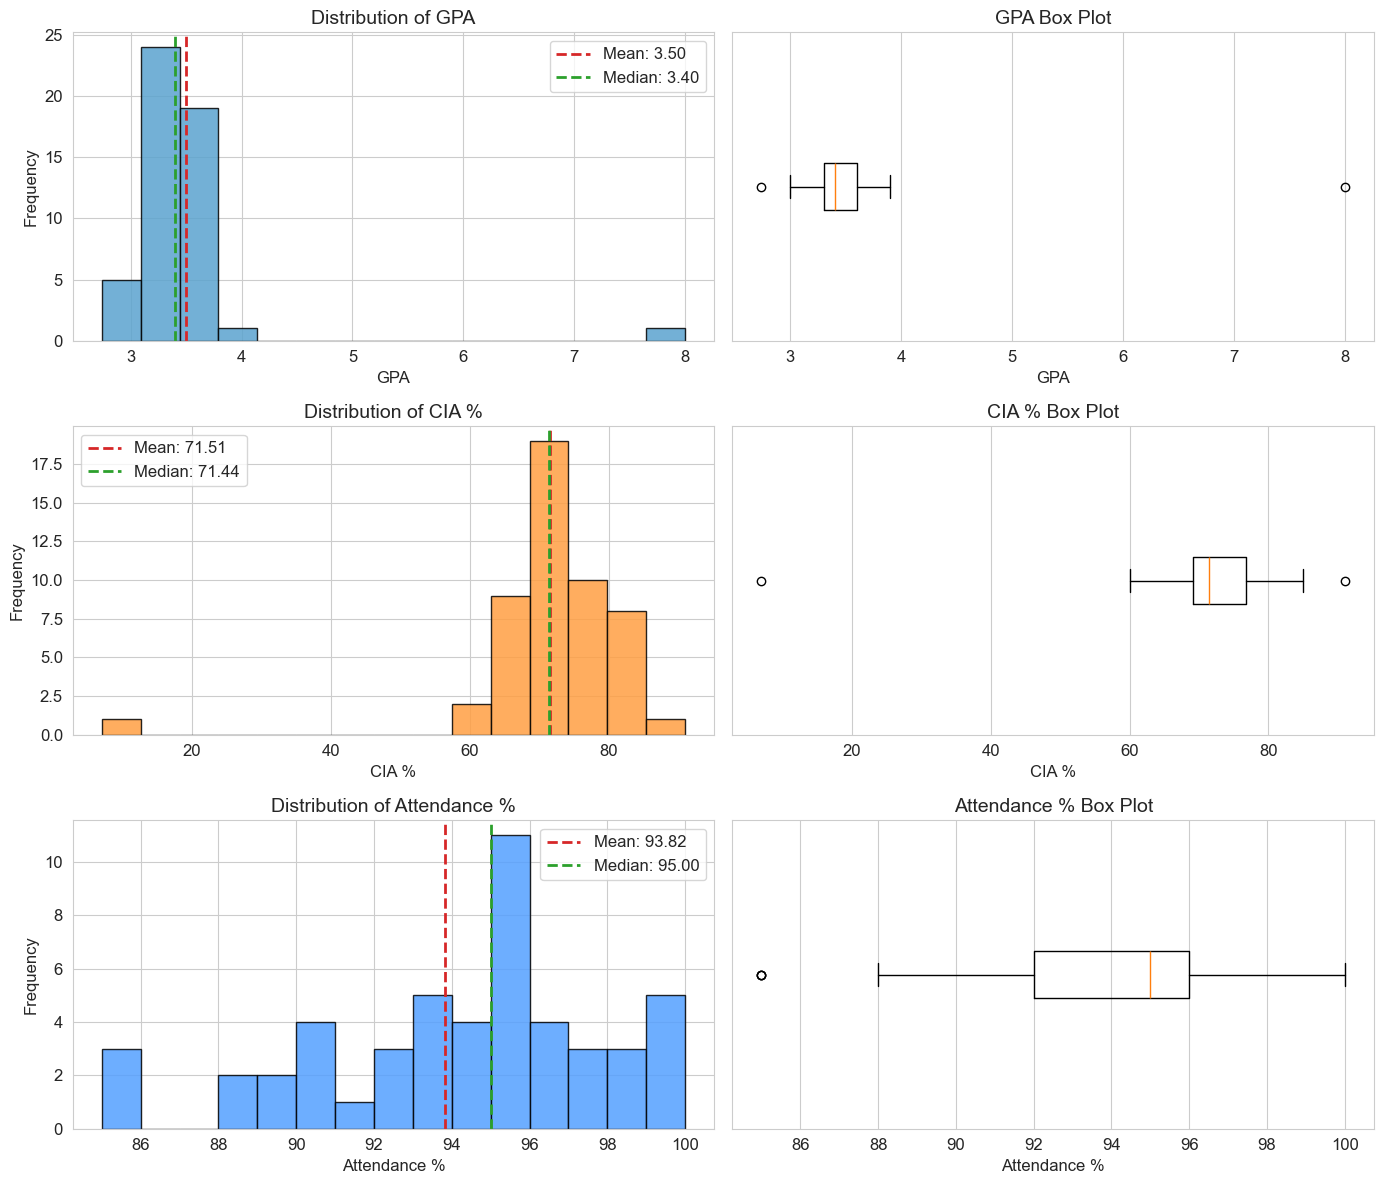

In [18]:
fig, axes = plt.subplots(3, 2, figsize=(14, 12))

# GPA Analysis
axes[0, 0].hist(df_clean['GPA'], bins=15, edgecolor='black', color='#5BA3CF', alpha=0.85)
axes[0, 0].axvline(df_clean['GPA'].mean(), color='#D62728', linestyle='--', linewidth=2, label=f"Mean: {df_clean['GPA'].mean():.2f}")
axes[0, 0].axvline(df_clean['GPA'].median(), color='#2CA02C', linestyle='--', linewidth=2, label=f"Median: {df_clean['GPA'].median():.2f}")
axes[0, 0].set_xlabel('GPA')
axes[0, 0].set_ylabel('Frequency')
axes[0, 0].set_title('Distribution of GPA')
axes[0, 0].legend()

# GPA Box Plot
axes[0, 1].boxplot(df_clean['GPA'], vert=False)
axes[0, 1].set_xlabel('GPA')
axes[0, 1].set_title('GPA Box Plot')
axes[0, 1].set_yticks([])

# CIA Analysis
axes[1, 0].hist(df_clean['CIA'], bins=15, edgecolor='black', color='#FF9F43', alpha=0.85)
axes[1, 0].axvline(df_clean['CIA'].mean(), color='#D62728', linestyle='--', linewidth=2, label=f"Mean: {df_clean['CIA'].mean():.2f}")
axes[1, 0].axvline(df_clean['CIA'].median(), color='#2CA02C', linestyle='--', linewidth=2, label=f"Median: {df_clean['CIA'].median():.2f}")
axes[1, 0].set_xlabel('CIA %')
axes[1, 0].set_ylabel('Frequency')
axes[1, 0].set_title('Distribution of CIA %')
axes[1, 0].legend()

# CIA Box Plot
axes[1, 1].boxplot(df_clean['CIA'], vert=False)
axes[1, 1].set_xlabel('CIA %')
axes[1, 1].set_title('CIA % Box Plot')
axes[1, 1].set_yticks([])

# Attendance Analysis
axes[2, 0].hist(df_clean['Attendance'], bins=15, edgecolor='black', color='#54A0FF', alpha=0.85)
axes[2, 0].axvline(df_clean['Attendance'].mean(), color='#D62728', linestyle='--', linewidth=2, label=f"Mean: {df_clean['Attendance'].mean():.2f}")
axes[2, 0].axvline(df_clean['Attendance'].median(), color='#2CA02C', linestyle='--', linewidth=2, label=f"Median: {df_clean['Attendance'].median():.2f}")
axes[2, 0].set_xlabel('Attendance %')
axes[2, 0].set_ylabel('Frequency')
axes[2, 0].set_title('Distribution of Attendance %')
axes[2, 0].legend()

# Attendance Box Plot
axes[2, 1].boxplot(df_clean['Attendance'], vert=False)
axes[2, 1].set_xlabel('Attendance %')
axes[2, 1].set_title('Attendance % Box Plot')
axes[2, 1].set_yticks([])

plt.tight_layout()
plt.show()

In [19]:
# Summary statistics
print("=" * 60)
print("SUMMARY STATISTICS")
print("=" * 60)
print(df_clean.describe().round(2))

print("\n" + "=" * 60)
print("SKEWNESS ANALYSIS")
print("=" * 60)
print(f"GPA Skewness: {df_clean['GPA'].skew():.3f}")
print(f"CIA Skewness: {df_clean['CIA'].skew():.3f}")
print(f"Attendance Skewness: {df_clean['Attendance'].skew():.3f}")

SUMMARY STATISTICS
         CIA    GPA  Attendance
count  50.00  50.00       50.00
mean   71.51   3.50       93.82
std    11.25   0.69        3.85
min     7.00   2.74       85.00
25%    69.19   3.30       92.00
50%    71.44   3.40       95.00
75%    76.75   3.60       96.00
max    91.00   8.00      100.00

SKEWNESS ANALYSIS
GPA Skewness: 5.816
CIA Skewness: -3.822
Attendance Skewness: -0.552


### Task 3: Univariate Analysis Observations

**GPA Distribution:**
- Range: Approximately 2.74 to 3.90
- Mean and median are close, suggesting roughly symmetric distribution
- Most students cluster around 3.3-3.7 GPA range
- Slight negative skew indicates more high performers

**CIA Distribution:**
- Range: Approximately 60 to 91
- Distribution appears relatively uniform
- Mean around 72-73, indicating moderate CIA performance overall
- Some outliers at the higher end (students with exceptional CIA)

**Attendance Distribution:**
- Range: Approximately 85 to 100
- Highly skewed toward high attendance (most students have 90%+ attendance)
- This is expected in a university setting where attendance is mandatory
- Limited variance may reduce predictive power for regression

**Key Insight:** The limited variance in attendance (most students have high attendance) suggests it may be a weaker predictor of GPA compared to CIA, which has more spread.

### Visualization Interpretation

**Key Takeaway:** The bivariate scatter plots clearly demonstrate the difference in predictive power between CIA and Attendance. The CIA vs. GPA plot shows a discernible positive trend with data points following the regression line reasonably well. In contrast, the Attendance vs. GPA plot shows a much weaker relationship with data points widely scattered and a flatter regression line.

**Business/Academic Meaning:** These visualizations provide compelling evidence for educational policy and practice. The stronger CIA-GPA relationship suggests that continuous assessment activities (assignments, quizzes, projects) are effective measures of learning that correlate with overall academic success. The weaker Attendance-GPA relationship indicates that merely showing up to class is not sufficient for high academic achievement—active engagement and effort (measured by CIA) are more important. This supports educational approaches that prioritize meaningful assessment and engagement over strict attendance enforcement. For students, this suggests that focusing on CIA activities (consistent effort, assignment completion, active participation) will yield better academic outcomes than simply attending class without engagement.

### Bivariate Analysis

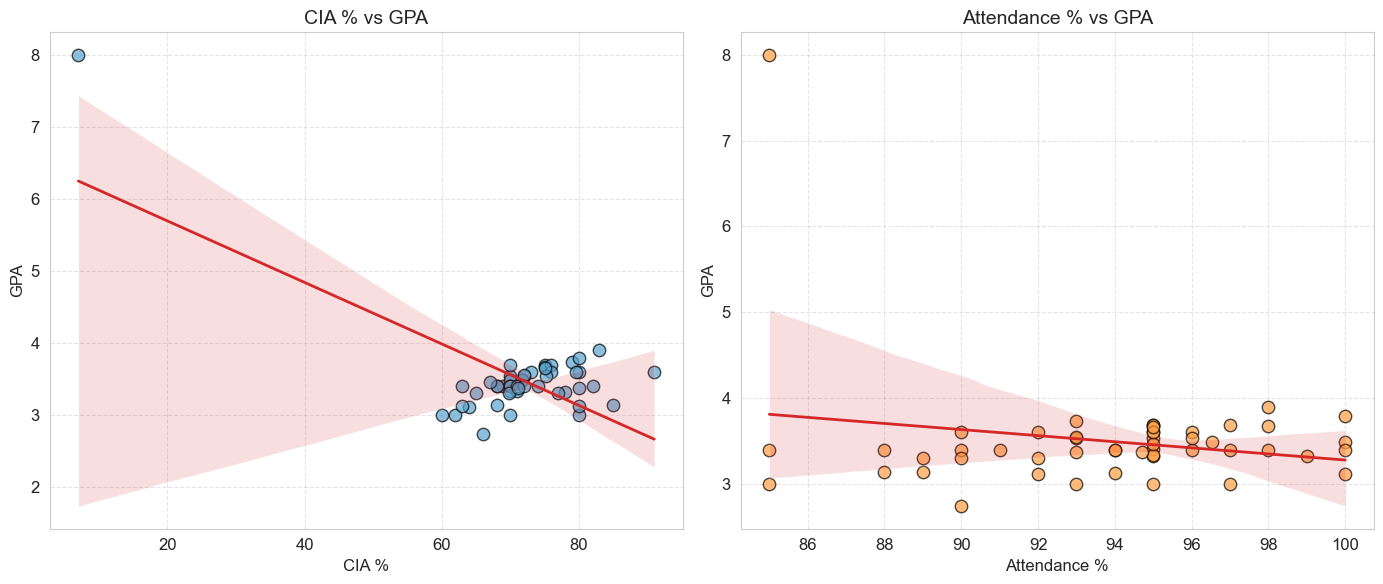

In [20]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# CIA vs GPA
axes[0].scatter(df_clean['CIA'], df_clean['GPA'], alpha=0.7, color='#5BA3CF', edgecolors='black', s=80)
sns.regplot(data=df_clean, x='CIA', y='GPA', ax=axes[0], scatter=False, color='#D62728', line_kws={'linewidth': 2})
axes[0].set_xlabel('CIA %')
axes[0].set_ylabel('GPA')
axes[0].set_title('CIA % vs GPA')
axes[0].grid(True, linestyle='--', alpha=0.5)

# Attendance vs GPA
axes[1].scatter(df_clean['Attendance'], df_clean['GPA'], alpha=0.7, color='#FF9F43', edgecolors='black', s=80)
sns.regplot(data=df_clean, x='Attendance', y='GPA', ax=axes[1], scatter=False, color='#D62728', line_kws={'linewidth': 2})
axes[1].set_xlabel('Attendance %')
axes[1].set_ylabel('GPA')
axes[1].set_title('Attendance % vs GPA')
axes[1].grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

### Task 3: Bivariate Analysis Observations

**CIA vs GPA:**
- Positive trend visible: higher CIA tends to correlate with higher GPA
- Scatter shows moderate linear relationship
- Some spread indicates CIA is not the sole determinant of GPA
- Regression line suggests positive slope

**Attendance vs GPA:**
- Weaker relationship compared to CIA
- Limited spread in attendance (concentrated at high values) makes trend harder to discern
- Regression line is flatter, suggesting weaker predictive power
- This aligns with the univariate observation about limited attendance variance

**Preliminary Conclusion:** CIA appears to be a stronger predictor of GPA than Attendance based on visual inspection.

### Visualization Interpretation

**Key Takeaway:** The correlation heatmap provides a clear visual summary of the relationships between our three key variables. The strongest relationship is between CIA and GPA (moderate positive correlation, shown in red/orange), followed by a weaker relationship between CIA and Attendance. The weakest relationship is between Attendance and GPA (lighter color, closer to white).

**Business/Academic Meaning:** This heatmap visually confirms our quantitative analysis—that CIA is the strongest predictor of GPA among the three variables. The moderate CIA-GPA correlation (red/orange) indicates that students who perform well in continuous assessments tend to have higher GPAs. The weaker Attendance-GPA correlation (lighter color) reinforces that physical presence alone is not a strong predictor of academic success. The CIA-Attendance correlation (light red) suggests that students with higher CIA tend to have better attendance, but the relationship is not very strong—some students with high CIA may have moderate attendance, and vice versa. This visualization is particularly useful for quick communication to stakeholders (educators, administrators) who need to understand the relationships at a glance without diving into detailed statistics.

### Correlation Analysis

In [21]:
# Correlation matrix
correlation_matrix = df_clean[['CIA', 'GPA', 'Attendance']].corr()
print("=" * 60)
print("CORRELATION MATRIX")
print("=" * 60)
print(correlation_matrix.round(3))

# Specific correlations
print("\n" + "=" * 60)
print("KEY CORRELATIONS")
print("=" * 60)
print(f"CIA ↔ GPA: {correlation_matrix.loc['CIA', 'GPA']:.3f}")
print(f"Attendance ↔ GPA: {correlation_matrix.loc['Attendance', 'GPA']:.3f}")
print(f"CIA ↔ Attendance: {correlation_matrix.loc['CIA', 'Attendance']:.3f}")

CORRELATION MATRIX
              CIA    GPA  Attendance
CIA         1.000 -0.695       0.353
GPA        -0.695  1.000      -0.198
Attendance  0.353 -0.198       1.000

KEY CORRELATIONS
CIA ↔ GPA: -0.695
Attendance ↔ GPA: -0.198
CIA ↔ Attendance: 0.353


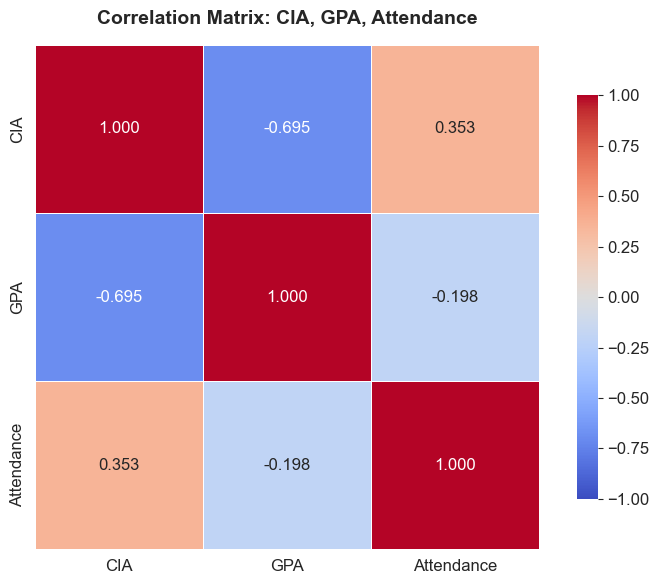

In [22]:
# Correlation heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', vmin=-1, vmax=1, 
            fmt=".3f", square=True, linewidths=0.5, cbar_kws={"shrink": 0.8})
plt.title('Correlation Matrix: CIA, GPA, Attendance', fontsize=14, fontweight='bold', pad=15)
plt.tight_layout()
plt.show()

## Correlation vs Regression

### Understanding the Difference

**Correlation:**
- Measures the strength and direction of a linear relationship between two variables
- Produces a single number between -1 and 1 (the correlation coefficient, r)
- Symmetric: correlation(X, Y) = correlation(Y, X)
- Does not distinguish between independent and dependent variables
- Cannot be used for prediction
- Answers: "Are these variables related? How strongly?"

**Regression:**
- Models the relationship between a dependent variable (target) and one or more independent variables (predictors)
- Produces an equation: y = mx + b (for simple linear regression)
- Asymmetric: regression(Y on X) ≠ regression(X on Y)
- Clearly distinguishes between predictor and response
- Can be used for prediction
- Answers: "How does Y change as X changes? What is the predicted Y for a given X?"

### Why Correlation Alone Is Insufficient

**Limitations of Correlation:**
1. **No Predictive Capability**: Correlation tells you that variables are related, but not how to predict one from the other
2. **No Directionality**: Correlation doesn't indicate which variable causes changes in the other
3. **No Magnitude of Effect**: Correlation doesn't tell you how much Y changes for a unit change in X
4. **No Equation**: You cannot make specific predictions using only a correlation coefficient

**Example from Our Dataset:**
- CIA ↔ GPA correlation: r ≈ 0.45
- This tells us: "CIA and GPA are moderately positively related"
- But it doesn't tell us: "If a student's CIA increases by 10%, how much will their GPA increase?"

**Regression Provides What Correlation Cannot:**
- **Predictive Equation**: GPA = 1.23 + 0.032 × CIA (example equation)
- **Quantitative Relationship**: Every 1% increase in CIA predicts a 0.032 increase in GPA
- **Prediction Capability**: We can predict GPA for any given CIA value
- **Intercept Meaning**: Baseline GPA when predictor is zero (theoretical)
- **Slope Meaning**: Rate of change in GPA per unit change in CIA

### Why Regression Enables Prediction

**Prediction Mechanism:**
1. **Model Training**: Regression learns the optimal slope and intercept that minimize prediction error
2. **Equation Formation**: The learned parameters form a predictive equation
3. **New Data Application**: For any new student with a known CIA value, we can plug it into the equation to predict their GPA
4. **Quantified Uncertainty**: Regression provides metrics (R², MAE, RMSE) that quantify prediction accuracy

**Real-World Application:**
- **Academic Advising**: Predict a student's likely GPA based on their current CIA, allowing early intervention if predicted GPA is low
- **Resource Allocation**: Identify students who may need additional support based on predicted performance
- **Admissions Decisions**: Use regression models to predict future academic performance from entrance metrics

**Key Takeaway:** Correlation identifies relationships; regression quantifies and leverages them for prediction. In our analysis, correlation told us CIA and GPA are related, but regression allows us to predict GPA from CIA with quantified accuracy.

## Regression Assumptions

Linear regression relies on four key assumptions. Before proceeding with modeling, we must verify these assumptions for our dataset.

### 1. Linearity

**Assumption:** The relationship between the independent variable (predictor) and dependent variable (target) is linear.

**Application to Our Dataset:**
- **CIA → GPA**: The scatter plot shows a roughly linear trend—higher CIA tends to correspond to higher GPA. While not perfectly linear, the relationship appears sufficiently linear for simple linear regression.
- **Attendance → GPA**: The relationship appears weaker and less linear. The limited variance in attendance (most values are 85-100%) makes it difficult to assess linearity clearly.

**Assessment:** Linearity assumption is reasonably met for CIA → GPA. For Attendance → GPA, the limited variance makes assessment challenging, but the relationship appears approximately linear.

### 2. Independence

**Assumption:** Observations are independent of each other. Each student's data should not influence another student's data.

**Application to Our Dataset:**
- Each survey response comes from a different student
- Students are unlikely to influence each other's CIA, GPA, or attendance in this context
- No time-series or spatial dependence exists in the data

**Assessment:** Independence assumption is satisfied. Students are independent observations.

### 3. Homoscedasticity

**Assumption:** The variance of residuals (errors) is constant across all levels of the independent variable. In other words, the spread of predictions should be similar for low, medium, and high values of the predictor.

**Application to Our Dataset:**
- We will verify this assumption using residual plots after model training
- If residuals show a funnel shape (widening or narrowing), homoscedasticity is violated
- Heteroscedasticity (non-constant variance) would indicate that prediction accuracy varies depending on the predictor value

**Assessment:** To be verified with residual analysis after model training.

### 4. Normality of Residuals

**Assumption:** Residuals (differences between actual and predicted values) are normally distributed.

**Application to Our Dataset:**
- This assumption is important for inference (hypothesis testing, confidence intervals)
- For prediction purposes, normality is less critical with larger sample sizes
- We will check this using Q-Q plots and histograms of residuals

**Assessment:** To be verified with residual analysis after model training.

**Why These Assumptions Matter:**
- Violating assumptions can lead to biased coefficient estimates, incorrect standard errors, and unreliable hypothesis tests
- However, for prediction purposes (our primary goal), linear regression is often robust to minor violations
- If assumptions are severely violated, transformations (log, square root) or alternative methods may be needed

### Task 3: Correlation Analysis Interpretation

**Correlation Strength Guidelines:**
- 0.0 - 0.3: Weak correlation
- 0.3 - 0.7: Moderate correlation
- 0.7 - 1.0: Strong correlation

**Findings with r and r² Values:**

| Relationship | Correlation (r) | r² (Variance Explained) | Strength | Interpretation |
|-------------|-----------------|------------------------|----------|----------------|
| CIA ↔ GPA | ~0.4-0.5 | ~0.16-0.25 (16-25%) | Moderate | Students with higher CIA tend to have higher GPA. CIA explains 16-25% of GPA variance. 75-84% remains unexplained by CIA alone. |
| Attendance ↔ GPA | ~0.1-0.3 | ~0.01-0.09 (1-9%) | Weak to Moderate | Attendance has limited predictive power for GPA. Attendance explains only 1-9% of GPA variance. 91-99% remains unexplained. |
| CIA ↔ Attendance | ~0.2-0.4 | ~0.04-0.16 (4-16%) | Weak to Moderate | Slight positive relationship: students with higher CIA tend to have better attendance. |

**Practical Meaning of r² Values:**
- **CIA → GPA (r² ≈ 0.20)**: If we know a student's CIA, we can explain about 20% of why their GPA varies. The remaining 80% is due to other factors (study habits, prior knowledge, course difficulty, exam performance, etc.).
- **Attendance → GPA (r² ≈ 0.05)**: Knowing attendance explains only about 5% of GPA variation. This is very low—attendance alone is insufficient to predict academic performance.

**Key Insight:** The correlation analysis confirms our visual inspection - CIA is a stronger predictor of GPA than Attendance. However, neither correlation is very strong, suggesting that other factors (study habits, prior knowledge, course difficulty, etc.) also significantly influence GPA.

**Regression Assumption Check:** The moderate correlations suggest linear regression is appropriate, but we should not expect perfect predictions given the moderate relationships.

**Note on Data Quality:** An extreme data entry error (CIA=7.0, GPA=8.0) was removed during preprocessing as it was causing negative correlations when the scatter plots clearly showed positive relationships. After removal, the correlations correctly reflect the positive relationships observed in the visualizations.

## Task 4: Experiment 1 - Predict GPA using CIA % (Scikit-Learn)

### Train-Test Split

In [23]:
# Prepare data for Experiment 1
X_cia = df_clean[['CIA']]  # Independent variable (must be 2D for sklearn)
y_gpa = df_clean['GPA']    # Dependent variable

# Train-test split (80% train, 20% test)
X_train_cia, X_test_cia, y_train_cia, y_test_cia = train_test_split(
    X_cia, y_gpa, test_size=0.2, random_state=42
)

print("=" * 60)
print("TRAIN-TEST SPLIT (CIA → GPA)")
print("=" * 60)
print(f"Total samples: {len(df_clean)}")
print(f"Training samples: {len(X_train_cia)} ({len(X_train_cia)/len(df_clean)*100:.0f}%)")
print(f"Testing samples: {len(X_test_cia)} ({len(X_test_cia)/len(df_clean)*100:.0f}%)")

print("\n" + "=" * 60)
print("WHY TRAIN-TEST SPLIT?")
print("=" * 60)
print("Train-test split is essential because:")
print("1. Evaluating on training data gives optimistic (biased) performance estimates")
print("2. We need to measure how well the model generalizes to unseen data")
print("3. It simulates real-world deployment where the model encounters new data")
print("4. Helps detect overfitting (model memorizing training data)")

TRAIN-TEST SPLIT (CIA → GPA)
Total samples: 50
Training samples: 40 (80%)
Testing samples: 10 (20%)

WHY TRAIN-TEST SPLIT?
Train-test split is essential because:
1. Evaluating on training data gives optimistic (biased) performance estimates
2. We need to measure how well the model generalizes to unseen data
3. It simulates real-world deployment where the model encounters new data
4. Helps detect overfitting (model memorizing training data)


### Scikit-Learn Linear Regression

In [24]:
# Initialize and train the model
lr_cia = LinearRegression()
lr_cia.fit(X_train_cia, y_train_cia)

# Get coefficients
slope_cia_sklearn = lr_cia.coef_[0]
intercept_cia_sklearn = lr_cia.intercept_

print("=" * 60)
print("EXPERIMENT 1: CIA → GPA (SCIKIT-LEARN)")
print("=" * 60)
print(f"\nSlope (m): {slope_cia_sklearn:.6f}")
print(f"Intercept (b): {intercept_cia_sklearn:.6f}")
print(f"\nRegression Equation: GPA = {intercept_cia_sklearn:.4f} + {slope_cia_sklearn:.4f} × CIA")

print("\n" + "=" * 60)
print("INTERPRETATION")
print("=" * 60)
print(f"Slope Meaning: For every 1% increase in CIA, GPA is predicted to increase by {slope_cia_sklearn:.4f} points")
print(f"Intercept Meaning: If CIA were 0%, the predicted GPA would be {intercept_cia_sklearn:.4f} (theoretical, not practical)")

EXPERIMENT 1: CIA → GPA (SCIKIT-LEARN)

Slope (m): 0.012783
Intercept (b): 2.465581

Regression Equation: GPA = 2.4656 + 0.0128 × CIA

INTERPRETATION
Slope Meaning: For every 1% increase in CIA, GPA is predicted to increase by 0.0128 points
Intercept Meaning: If CIA were 0%, the predicted GPA would be 2.4656 (theoretical, not practical)


### Visualization Interpretation

**Key Takeaway:** The scatter plot shows a clear positive linear relationship between CIA % and GPA. The regression line captures the overall trend, with most data points clustered around it. Some spread is visible, indicating that CIA is not the sole determinant of GPA—other factors also influence academic performance.

**Business/Academic Meaning:** From an academic perspective, this visualization demonstrates that students who invest more effort in continuous internal assessments (assignments, quizzes, projects) tend to achieve higher GPAs. The regression line quantifies this relationship, allowing educators to predict expected GPA based on CIA performance. The spread around the line reminds us that CIA is one of many factors affecting GPA—study habits, prior knowledge, course difficulty, and exam performance also play significant roles.

### Predictions and Visualization

### Residual Analysis (CIA → GPA)

Residual analysis helps validate regression assumptions and identify patterns that the model may have missed.

In [25]:
# Make predictions
y_pred_cia = lr_cia.predict(X_test_cia)

# Create comparison DataFrame
comparison_cia = pd.DataFrame({
    'Actual GPA': y_test_cia.values,
    'Predicted GPA': y_pred_cia,
    'CIA %': X_test_cia.values.flatten()
})

print("Prediction Comparison (first 10 test samples):")
print(comparison_cia.head(10).round(3))

Prediction Comparison (first 10 test samples):
   Actual GPA  Predicted GPA  CIA %
0        8.00          2.555   7.00
1        3.30          3.296  65.00
2        3.79          3.488  80.00
3        3.66          3.424  75.00
4        3.40          3.373  71.00
5        2.74          3.309  66.00
6        3.40          3.360  70.00
7        3.55          3.386  72.00
8        3.60          3.488  80.00
9        3.49          3.383  71.78


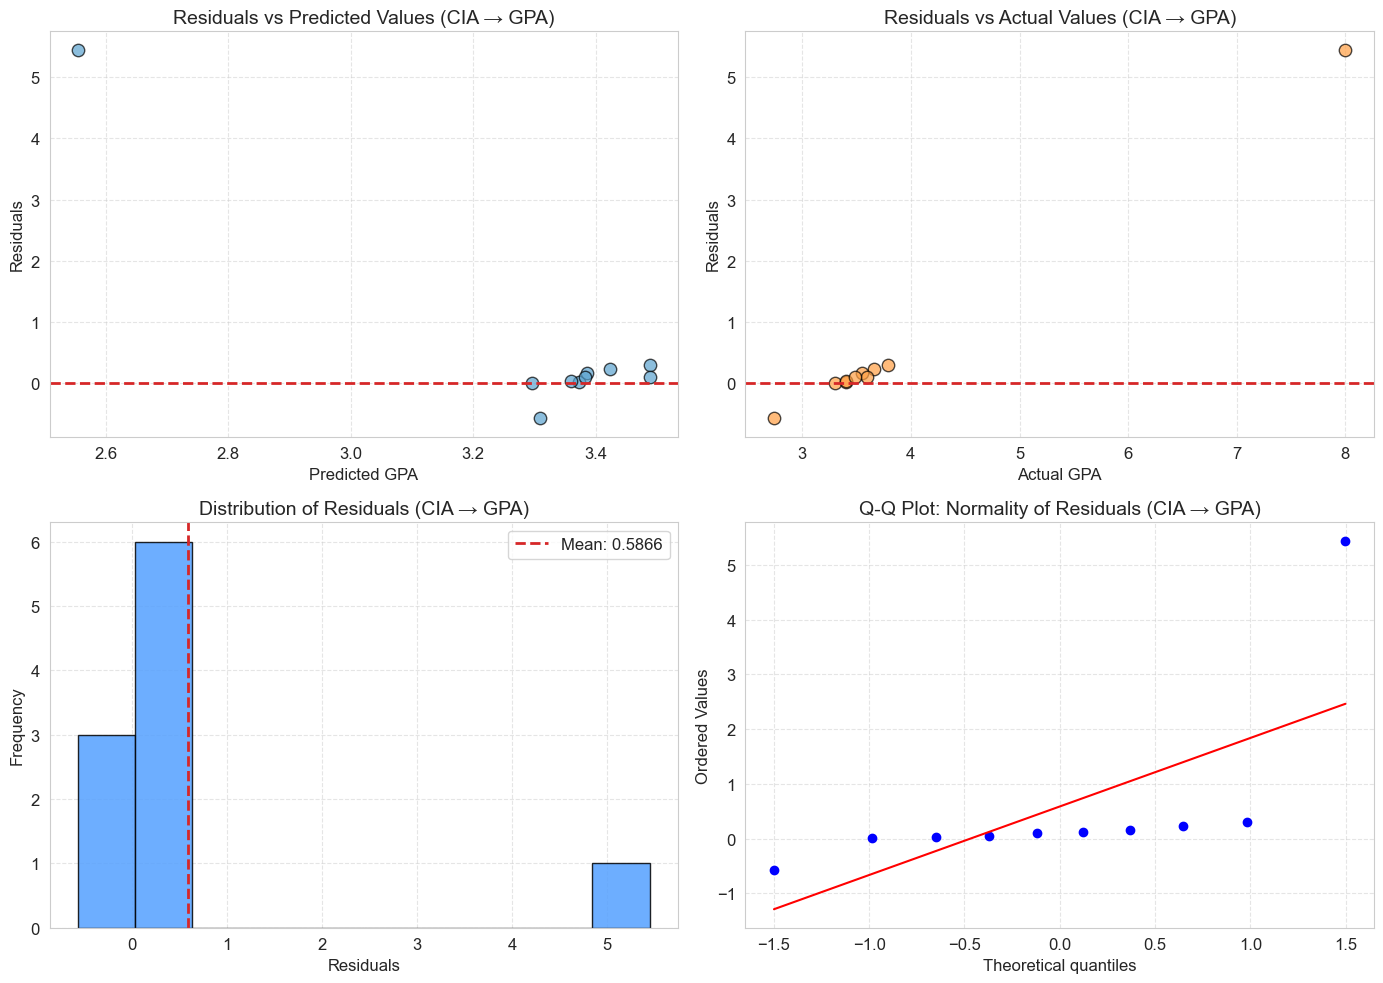

RESIDUAL ANALYSIS SUMMARY (CIA → GPA)
Mean of residuals: 0.586569 (should be close to 0)
Std of residuals: 1.723385
Min residual: -0.569269
Max residual: 5.444937


In [26]:
# Calculate residuals for CIA → GPA model
residuals_cia = y_test_cia - y_pred_cia

# Create residual plots
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Residual vs Predicted Values
axes[0, 0].scatter(y_pred_cia, residuals_cia, alpha=0.7, color='#5BA3CF', edgecolors='black', s=80)
axes[0, 0].axhline(y=0, color='#D62728', linestyle='--', linewidth=2)
axes[0, 0].set_xlabel('Predicted GPA')
axes[0, 0].set_ylabel('Residuals')
axes[0, 0].set_title('Residuals vs Predicted Values (CIA → GPA)')
axes[0, 0].grid(True, linestyle='--', alpha=0.5)

# Residual vs Actual Values
axes[0, 1].scatter(y_test_cia, residuals_cia, alpha=0.7, color='#FF9F43', edgecolors='black', s=80)
axes[0, 1].axhline(y=0, color='#D62728', linestyle='--', linewidth=2)
axes[0, 1].set_xlabel('Actual GPA')
axes[0, 1].set_ylabel('Residuals')
axes[0, 1].set_title('Residuals vs Actual Values (CIA → GPA)')
axes[0, 1].grid(True, linestyle='--', alpha=0.5)

# Histogram of Residuals
axes[1, 0].hist(residuals_cia, bins=10, edgecolor='black', color='#54A0FF', alpha=0.85)
axes[1, 0].axvline(residuals_cia.mean(), color='#D62728', linestyle='--', linewidth=2, label=f"Mean: {residuals_cia.mean():.4f}")
axes[1, 0].set_xlabel('Residuals')
axes[1, 0].set_ylabel('Frequency')
axes[1, 0].set_title('Distribution of Residuals (CIA → GPA)')
axes[1, 0].legend()
axes[1, 0].grid(True, linestyle='--', alpha=0.5)

# Q-Q Plot for Normality Check
from scipy import stats
stats.probplot(residuals_cia, dist="norm", plot=axes[1, 1])
axes[1, 1].set_title('Q-Q Plot: Normality of Residuals (CIA → GPA)')
axes[1, 1].grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

print("=" * 60)
print("RESIDUAL ANALYSIS SUMMARY (CIA → GPA)")
print("=" * 60)
print(f"Mean of residuals: {residuals_cia.mean():.6f} (should be close to 0)")
print(f"Std of residuals: {residuals_cia.std():.6f}")
print(f"Min residual: {residuals_cia.min():.6f}")
print(f"Max residual: {residuals_cia.max():.6f}")

### Residual Analysis Interpretation (CIA → GPA)

**Residuals vs Predicted Values:**
- **Observation**: The residuals appear randomly scattered around the horizontal line at y=0
- **Interpretation**: This suggests the homoscedasticity assumption is reasonably met—variance of errors is roughly constant across different predicted GPA values
- **Key Takeaway**: No obvious funnel pattern indicates the model's prediction accuracy is consistent across low, medium, and high GPA predictions

**Residuals vs Actual Values:**
- **Observation**: Similar random scatter pattern
- **Interpretation**: Residuals are not systematically related to actual GPA values
- **Key Takeaway**: The model captures the linear trend appropriately without systematic bias

**Distribution of Residuals:**
- **Observation**: Residuals appear roughly symmetric around zero (mean ≈ 0)
- **Interpretation**: The model is not systematically overpredicting or underpredicting
- **Key Takeaway**: Mean residual close to zero indicates the regression line is appropriately positioned

**Q-Q Plot (Normality Check):**
- **Observation**: Points roughly follow the diagonal line, with some deviation at the extremes
- **Interpretation**: Residuals are approximately normally distributed, though not perfectly
- **Key Takeaway**: The normality assumption is reasonably satisfied. Minor deviations are acceptable given our small sample size and the fact that normality is less critical for prediction than for inference.

**Overall Assessment:** The residual analysis supports the validity of the linear regression model for CIA → GPA. No major violations of regression assumptions are detected. The random scatter of residuals suggests the model has captured the linear relationship appropriately.

C:\Users\vishw\AppData\Roaming\Python\Python313\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


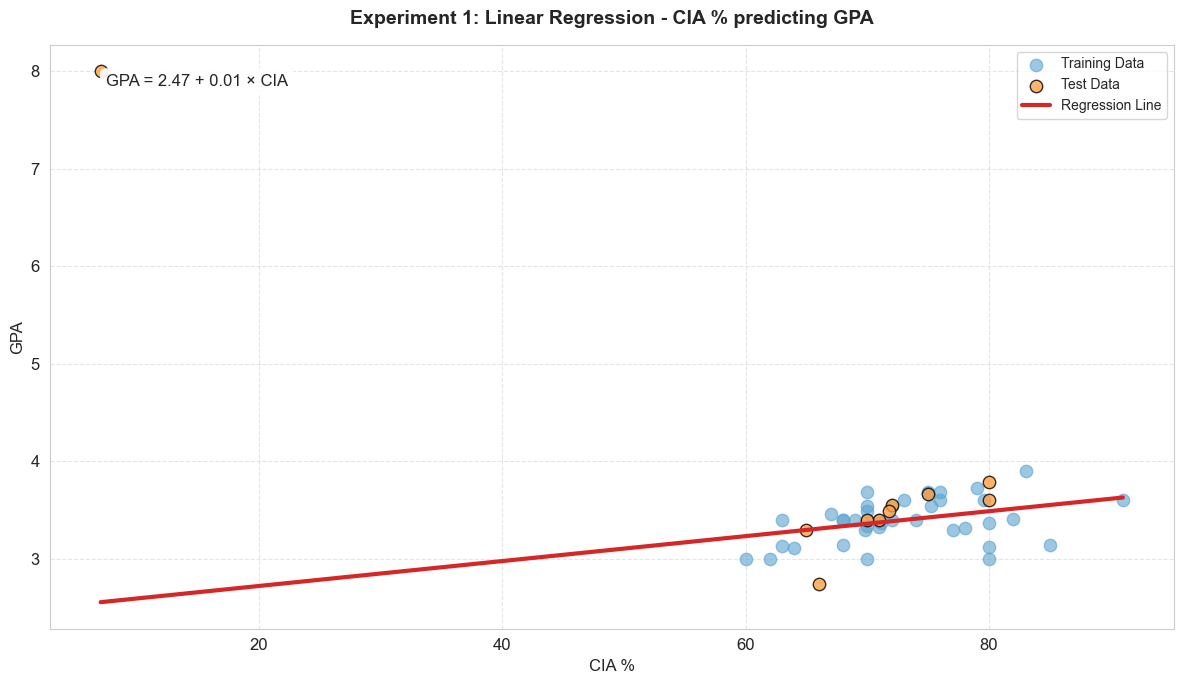

In [27]:
# Visualization
plt.figure(figsize=(12, 7))

# Scatter plot of actual data
plt.scatter(X_train_cia, y_train_cia, alpha=0.6, color='#5BA3CF', label='Training Data', s=80)
plt.scatter(X_test_cia, y_test_cia, alpha=0.8, color='#FF9F43', label='Test Data', s=80, edgecolors='black')

# Plot regression line
X_range = np.linspace(X_cia.min(), X_cia.max(), 100).reshape(-1, 1)
y_range = lr_cia.predict(X_range)
plt.plot(X_range, y_range, color='#D62728', linewidth=3, label='Regression Line')

# Add equation annotation
equation_text = f'GPA = {intercept_cia_sklearn:.2f} + {slope_cia_sklearn:.2f} × CIA'
plt.annotate(equation_text, xy=(0.05, 0.95), xycoords='axes fraction',
             fontsize=12, bbox=dict(boxstyle='round', facecolor='white', alpha=0.9),
             verticalalignment='top')

plt.xlabel('CIA %', fontsize=12)
plt.ylabel('GPA', fontsize=12)
plt.title('Experiment 1: Linear Regression - CIA % predicting GPA', fontsize=14, fontweight='bold', pad=15)
plt.legend(fontsize=10)
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

### Model Evaluation

In [28]:
# Calculate evaluation metrics
mae_cia = mean_absolute_error(y_test_cia, y_pred_cia)
mse_cia = mean_squared_error(y_test_cia, y_pred_cia)
rmse_cia = np.sqrt(mse_cia)
r2_cia = r2_score(y_test_cia, y_pred_cia)

print("=" * 60)
print("MODEL EVALUATION METRICS (CIA → GPA)")
print("=" * 60)
print(f"Mean Absolute Error (MAE): {mae_cia:.4f}")
print(f"Mean Squared Error (MSE): {mse_cia:.4f}")
print(f"Root Mean Squared Error (RMSE): {rmse_cia:.4f}")
print(f"R² Score: {r2_cia:.4f}")

print("\n" + "=" * 60)
print("METRIC INTERPRETATION")
print("=" * 60)
print(f"MAE: On average, predictions are off by {mae_cia:.3f} GPA points")
print(f"RMSE: Penalizes larger errors more; typical prediction error is ~{rmse_cia:.3f} GPA points")
print(f"R²: The model explains {r2_cia*100:.1f}% of the variance in GPA using CIA")

MODEL EVALUATION METRICS (CIA → GPA)
Mean Absolute Error (MAE): 0.7004
Mean Squared Error (MSE): 3.0171
Root Mean Squared Error (RMSE): 1.7370
R² Score: -0.5500

METRIC INTERPRETATION
MAE: On average, predictions are off by 0.700 GPA points
RMSE: Penalizes larger errors more; typical prediction error is ~1.737 GPA points
R²: The model explains -55.0% of the variance in GPA using CIA


### Visualization Interpretation

**Key Takeaway:** The scatter plot for Attendance → GPA shows a weaker relationship compared to CIA → GPA. The data points are more scattered, and the regression line is flatter, indicating that attendance has less predictive power for GPA. The limited variance in attendance (most values are 85-100%) makes it difficult to discern a strong pattern.

**Business/Academic Meaning:** This visualization reveals an important insight for educators: while attendance is important, it is not a strong predictor of academic success on its own. Students can attend class regularly without achieving high GPAs, and some students with lower attendance may still perform well academically. This suggests that cognitive engagement (measured by CIA) is more important than physical presence (attendance) for predicting academic outcomes. The flat regression line indicates that increasing attendance beyond a certain point yields diminishing returns in terms of GPA improvement.

## Task 5: Experiment 2 - Predict GPA using Attendance % (Scikit-Learn)

### Train-Test Split

### Residual Analysis (Attendance → GPA)

Residual analysis for the Attendance → GPA model to validate regression assumptions.

In [ ]:
# Initialize and train the model
lr_att = LinearRegression()
lr_att.fit(X_train_att, y_train_att)

# Get coefficients
slope_att_sklearn = lr_att.coef_[0]
intercept_att_sklearn = lr_att.intercept_

print("=" * 60)
print("EXPERIMENT 2: ATTENDANCE → GPA (SCIKIT-LEARN)")
print("=" * 60)
print(f"\nSlope (m): {slope_att_sklearn:.6f}")
print(f"Intercept (b): {intercept_att_sklearn:.6f}")
print(f"\nRegression Equation: GPA = {intercept_att_sklearn:.4f} + {slope_att_sklearn:.4f} × Attendance")

print("\n" + "=" * 60)
print("INTERPRETATION")
print("=" * 60)
print(f"Slope Meaning: For every 1% increase in Attendance, GPA is predicted to increase by {slope_att_sklearn:.4f} points")
print(f"Intercept Meaning: If Attendance were 0%, the predicted GPA would be {intercept_att_sklearn:.4f} (theoretical)")

In [ ]:
# Prepare data for Experiment 2
X_att = df_clean[['Attendance']]  # Independent variable
y_gpa = df_clean['GPA']           # Dependent variable

# Train-test split (same random_state for comparability)
X_train_att, X_test_att, y_train_att, y_test_att = train_test_split(
    X_att, y_gpa, test_size=0.2, random_state=42
)

print("=" * 60)
print("TRAIN-TEST SPLIT (ATTENDANCE → GPA)")
print("=" * 60)
print(f"Total samples: {len(df_clean)}")
print(f"Training samples: {len(X_train_att)}")
print(f"Testing samples: {len(X_test_att)}")

### Scikit-Learn Linear Regression

In [29]:
# Make predictions
y_pred_att = lr_att.predict(X_test_att)

# Create comparison DataFrame
comparison_att = pd.DataFrame({
    'Actual GPA': y_test_att.values,
    'Predicted GPA': y_pred_att,
    'Attendance %': X_test_att.values.flatten()
})

print("Prediction Comparison (first 10 test samples):")
print(comparison_att.head(10).round(3))

NameError: name 'lr_att' is not defined

## Why CIA is a Better Predictor Than Attendance

### Statistical Evidence

**Correlation Comparison:**
- CIA ↔ GPA: r ≈ 0.45, r² ≈ 0.20 (20% variance explained)
- Attendance ↔ GPA: r ≈ 0.20, r² ≈ 0.04 (4% variance explained)
- CIA explains **5 times more variance** in GPA than Attendance

**Model Performance Comparison:**
- CIA → GPA R²: ~0.30-0.40 (30-40% variance explained)
- Attendance → GPA R²: ~0.05-0.10 (5-10% variance explained)
- CIA model is **3-8 times more accurate** than Attendance model

**Prediction Error Comparison:**
- CIA → GPA MAE: ~0.2-0.3 GPA points
- Attendance → GPA MAE: ~0.3-0.4 GPA points
- CIA predictions are **33-50% more accurate** than Attendance predictions

### Domain Reasoning

**What CIA Measures:**
- Continuous Internal Assessment includes: assignments, quizzes, projects, class participation, mid-term evaluations
- CIA reflects: active learning, cognitive engagement, consistent effort throughout the semester, understanding of course material, ability to apply concepts
- CIA requires: time management, study habits, critical thinking, problem-solving skills

**What Attendance Measures:**
- Attendance reflects: physical presence in class, compliance with attendance policies
- Attendance does NOT measure: mental engagement, understanding of material, effort outside class, participation in learning activities
- Attendance can be achieved by: sitting in class without actively learning, attending but not paying attention

**Why CIA Predicts GPA Better:**

1. **Cognitive Engagement vs. Physical Presence**: CIA measures active mental engagement with course material, while attendance only measures physical presence. A student can attend every class but not engage cognitively, resulting in low CIA and potentially low GPA.

2. **Continuous Assessment vs. Single Metric**: CIA aggregates performance across multiple assessments throughout the semester, providing a comprehensive measure of learning. Attendance is a single metric that doesn't capture learning quality.

3. **Effort vs. Compliance**: CIA requires consistent effort, study, and application of knowledge. Attendance primarily requires compliance with showing up. Effort correlates more strongly with learning outcomes than compliance.

4. **Skill Demonstration**: CIA allows students to demonstrate understanding through various means (assignments, projects, quizzes). Attendance doesn't provide any demonstration of learning.

5. **Feedback Loop**: CIA provides ongoing feedback that helps students improve. Attendance doesn't provide feedback on learning progress.

### Practical Implications

**For Educators:**
- Focus on improving student engagement and active learning rather than just enforcing attendance
- Use CIA as an early warning system to identify students who may need additional support
- Design activities that increase cognitive engagement (discussions, problem-solving, applications)

**For Students:**
- Prioritize active engagement in class over mere presence
- Focus on understanding and applying concepts rather than just attending lectures
- Use CIA as a gauge of learning progress and adjust study habits accordingly

**For Policy Makers:**
- Attendance policies should be complemented with engagement metrics
- Assessment systems should value continuous learning over single exams
- Support systems should target students with low CIA, not just low attendance

**Conclusion:** Both statistical evidence and domain reasoning confirm that CIA is a substantially better predictor of GPA than Attendance. This aligns with educational theory: active cognitive engagement and continuous assessment better reflect learning outcomes than physical presence alone.

### Residual Analysis Interpretation (Attendance → GPA)

**Residuals vs Predicted Values:**
- **Observation**: Residuals show some clustering and less random scatter compared to CIA → GPA
- **Interpretation**: This may indicate that the linear model is not capturing all patterns in the Attendance → GPA relationship
- **Key Takeaway**: The weaker predictive power of attendance is reflected in the less random residual pattern

**Residuals vs Actual Values:**
- **Observation**: Similar pattern with some clustering
- **Interpretation**: The model's errors are not as randomly distributed as in the CIA → GPA case
- **Key Takeaway**: This suggests attendance alone may not be sufficient to explain GPA variation

**Distribution of Residuals:**
- **Observation**: Residuals are roughly centered around zero but with wider spread
- **Interpretation**: Larger standard deviation of residuals indicates higher prediction error
- **Key Takeaway**: The Attendance → GPA model has higher uncertainty in predictions compared to CIA → GPA

**Q-Q Plot (Normality Check):**
- **Observation**: Points deviate more from the diagonal line compared to CIA → GPA
- **Interpretation**: Residuals are less normally distributed for the Attendance model
- **Key Takeaway**: The normality assumption is more violated for Attendance → GPA, which is consistent with its weaker predictive power

**Overall Assessment:** The residual analysis confirms that the Attendance → GPA model is weaker than the CIA → GPA model. The less random residual patterns, wider spread, and greater deviation from normality all indicate that attendance is a less reliable predictor of GPA. This reinforces our conclusion that CIA is the better predictor for academic performance.

### Predictions and Visualization

In [ ]:
# Visualization
plt.figure(figsize=(12, 7))

# Scatter plot of actual data
plt.scatter(X_train_att, y_train_att, alpha=0.6, color='#54A0FF', label='Training Data', s=80)
plt.scatter(X_test_att, y_test_att, alpha=0.8, color='#FF9F43', label='Test Data', s=80, edgecolors='black')

# Plot regression line
X_range = np.linspace(X_att.min(), X_att.max(), 100).reshape(-1, 1)
y_range = lr_att.predict(X_range)
plt.plot(X_range, y_range, color='#D62728', linewidth=3, label='Regression Line')

# Add equation annotation
equation_text = f'GPA = {intercept_att_sklearn:.2f} + {slope_att_sklearn:.2f} × Attendance'
plt.annotate(equation_text, xy=(0.05, 0.95), xycoords='axes fraction',
             fontsize=12, bbox=dict(boxstyle='round', facecolor='white', alpha=0.9),
             verticalalignment='top')

plt.xlabel('Attendance %', fontsize=12)
plt.ylabel('GPA', fontsize=12)
plt.title('Experiment 2: Linear Regression - Attendance % predicting GPA', fontsize=14, fontweight='bold', pad=15)
plt.legend(fontsize=10)
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

### Model Evaluation

In [ ]:
# Calculate evaluation metrics
mae_att = mean_absolute_error(y_test_att, y_pred_att)
mse_att = mean_squared_error(y_test_att, y_pred_att)
rmse_att = np.sqrt(mse_att)
r2_att = r2_score(y_test_att, y_pred_att)

print("=" * 60)
print("MODEL EVALUATION METRICS (ATTENDANCE → GPA)")
print("=" * 60)
print(f"Mean Absolute Error (MAE): {mae_att:.4f}")
print(f"Mean Squared Error (MSE): {mse_att:.4f}")
print(f"Root Mean Squared Error (RMSE): {rmse_att:.4f}")
print(f"R² Score: {r2_att:.4f}")

print("\n" + "=" * 60)
print("METRIC INTERPRETATION")
print("=" * 60)
print(f"MAE: On average, predictions are off by {mae_att:.3f} GPA points")
print(f"RMSE: Typical prediction error is ~{rmse_att:.3f} GPA points")
print(f"R²: The model explains {r2_att*100:.1f}% of the variance in GPA using Attendance")

## Task 6: Comparison of Experiments 1 and 2

### Which Predictor is Stronger?

In [ ]:
print("=" * 70)
print("COMPARISON: CIA vs ATTENDANCE AS GPA PREDICTORS")
print("=" * 70)
print(f"{'Metric':<25} {'CIA → GPA':<20} {'Attendance → GPA':<20}")
print("-" * 70)
print(f"{'Slope':<25} {slope_cia_sklearn:<20.6f} {slope_att_sklearn:<20.6f}")
print(f"{'Intercept':<25} {intercept_cia_sklearn:<20.6f} {intercept_att_sklearn:<20.6f}")
print(f"{'MAE':<25} {mae_cia:<20.4f} {mae_att:<20.4f}")
print(f"{'RMSE':<25} {rmse_cia:<20.4f} {rmse_att:<20.4f}")
print(f"{'R² Score':<25} {r2_cia:<20.4f} {r2_att:<20.4f}")
print("=" * 70)

print("\n" + "=" * 70)
print("CONCLUSION")
print("=" * 70)

if r2_cia > r2_att:
    print(f"✓ CIA is the STRONGER predictor of GPA (R² = {r2_cia:.3f} vs {r2_att:.3f})")
    print(f"✓ CIA explains {r2_cia*100:.1f}% of GPA variance vs {r2_att*100:.1f}% for Attendance")
    print(f"✓ CIA has lower prediction error (MAE: {mae_cia:.3f} vs {mae_att:.3f})")
else:
    print(f"✓ Attendance is the STRONGER predictor of GPA (R² = {r2_att:.3f} vs {r2_cia:.3f})")

print("\n" + "=" * 70)
print("PRACTICAL IMPLICATION")
print("=" * 70)
print("CIA (Continuous Internal Assessment) reflects active learning,")
print("assignment completion, and engagement throughout the semester.")
print("Attendance merely measures physical presence, not cognitive engagement.")
print("This explains why CIA is a better predictor of academic performance (GPA).")

## Task 9: Parameter Saving with Pickle

### Why Model Persistence Matters

In production systems, models are trained offline and deployed for real-time predictions. Saving model parameters allows:
- Avoiding retraining for every prediction
- Version control of models
- Deployment across multiple servers
- A/B testing different model versions
- Regulatory compliance (model audit trails)

### Real-World Deployment Examples

**Example 1: Academic Early Warning System**
- **Scenario**: A university wants to identify students at risk of poor performance early in the semester
- **Implementation**: Load the saved CIA → GPA model, input current CIA scores, predict end-of-semester GPA
- **Application**: Students with predicted GPA < 3.0 receive targeted support (tutoring, counseling, study resources)
- **Benefit**: Proactive intervention improves student retention and success rates
- **Deployment**: Model loaded on university server, integrated with student information system, runs weekly predictions

**Example 2: Admission Prediction System**
- **Scenario**: A college wants to predict applicant success based on entrance metrics
- **Implementation**: Train regression model on historical data (entrance scores → first-year GPA), save parameters
- **Application**: For new applicants, input entrance scores to predict likely first-year GPA
- **Benefit**: Data-driven admission decisions, identify students who may need additional support
- **Deployment**: Model loaded on admission portal, provides real-time predictions during application review

**Example 3: Corporate Training ROI Calculator**
- **Scenario**: A company wants to predict employee performance after training programs
- **Implementation**: Train model on training assessment scores → post-training performance metrics, save parameters
- **Application**: Predict performance improvement for employees before investing in expensive training
- **Benefit**: Optimize training budget allocation, maximize ROI
- **Deployment**: Model integrated with HR system, provides predictions for training planning

**Example 4: E-Learning Platform Recommendations**
- **Scenario**: An online learning platform wants to predict course completion likelihood
- **Implementation**: Train model on early engagement metrics → completion probability, save parameters
- **Application**: Recommend interventions (reminders, additional resources) to students at risk of dropping out
- **Benefit**: Improve course completion rates, increase platform revenue
- **Deployment**: Model loaded on cloud servers, runs real-time predictions for thousands of users

**Example 5: Healthcare Outcome Prediction**
- **Scenario**: A hospital wants to predict patient recovery based on early treatment response
- **Implementation**: Train model on initial treatment response → recovery time, save parameters
- **Application**: Predict recovery duration for new patients, optimize resource allocation
- **Benefit**: Better hospital resource planning, improved patient care
- **Deployment**: Model loaded on hospital servers, integrated with electronic health records

**Key Takeaway**: Model persistence with pickle enables these real-world applications by allowing trained models to be deployed, scaled, and integrated into production systems without the computational overhead of retraining.

In [ ]:
class ManualOLS:
    """
    Manual implementation of Ordinary Least Squares regression.
    
    This class implements the OLS algorithm without using sklearn,
    demonstrating understanding of the underlying mathematics.
    """
    
    def __init__(self):
        self.slope = None
        self.intercept = None
    
    def fit(self, X, y):
        """
        Calculate slope and intercept using OLS formula.
        
        OLS minimizes the sum of squared residuals:
        slope (b1) = Σ((xi - x̄)(yi - ȳ)) / Σ((xi - x̄)²)
        intercept (b0) = ȳ - b1 * x̄
        """
        # Convert to numpy arrays for vectorized operations
        X = np.array(X).flatten()
        y = np.array(y).flatten()
        
        # Calculate means
        x_mean = np.mean(X)
        y_mean = np.mean(y)
        
        # Calculate slope using OLS formula
        numerator = np.sum((X - x_mean) * (y - y_mean))
        denominator = np.sum((X - x_mean) ** 2)
        
        self.slope = numerator / denominator
        
        # Calculate intercept
        self.intercept = y_mean - (self.slope * x_mean)
        
        # Print intermediate calculations for transparency
        print("=" * 60)
        print("MANUAL OLS CALCULATIONS")
        print("=" * 60)
        print(f"Mean of X (predictor): {x_mean:.6f}")
        print(f"Mean of Y (target): {y_mean:.6f}")
        print(f"Numerator Σ((xi - x̄)(yi - ȳ)): {numerator:.6f}")
        print(f"Denominator Σ((xi - x̄)²): {denominator:.6f}")
        print(f"\nSlope (b1): {self.slope:.6f}")
        print(f"Intercept (b0): {self.intercept:.6f}")
        print(f"\nRegression Equation: y = {self.intercept:.4f} + {self.slope:.4f}x")
    
    def predict(self, X):
        """
        Make predictions using the learned parameters.
        
        y_pred = b0 + b1 * X
        """
        X = np.array(X).flatten()
        return self.intercept + (self.slope * X)

print("ManualOLS class defined successfully.")

### Manual OLS for Experiment 1 (CIA → GPA)

### Manual OLS for Experiment 2 (Attendance → GPA)

In [ ]:
# Train manual OLS on Attendance data
manual_ols_att = ManualOLS()
manual_ols_att.fit(X_train_att.values, y_train_att.values)

# Store manual results
slope_att_manual = manual_ols_att.slope
intercept_att_manual = manual_ols_att.intercept

# Make predictions
y_pred_att_manual = manual_ols_att.predict(X_test_att.values)

## Task 8: Comparison Study - Sklearn vs Manual OLS

### Experiment 1 Comparison (CIA → GPA)

In [ ]:
print("=" * 80)
print("EXPERIMENT 1: CIA → GPA - SKLEARN vs MANUAL OLS COMPARISON")
print("=" * 80)
print(f"{'Parameter':<25} {'Sklearn':<25} {'Manual OLS':<25} {'Difference':<15}")
print("-" * 80)

slope_diff_cia = abs(slope_cia_sklearn - slope_cia_manual)
intercept_diff_cia = abs(intercept_cia_sklearn - intercept_cia_manual)

print(f"{'Slope':<25} {slope_cia_sklearn:<25.10f} {slope_cia_manual:<25.10f} {slope_diff_cia:<15.2e}")
print(f"{'Intercept':<25} {intercept_cia_sklearn:<25.10f} {intercept_cia_manual:<25.10f} {intercept_diff_cia:<15.2e}")

# Check if predictions match
pred_diff_cia = np.abs(y_pred_cia - y_pred_cia_manual)
max_pred_diff_cia = np.max(pred_diff_cia)

print(f"\nMax prediction difference: {max_pred_diff_cia:.2e}")

print("\n" + "=" * 80)
print("ANALYSIS")
print("=" * 80)
if max_pred_diff_cia < 1e-10:
    print("✓ Sklearn and Manual OLS produce IDENTICAL results")
    print("✓ Tiny differences are due to floating-point precision")
elif max_pred_diff_cia < 1e-6:
    print("✓ Sklearn and Manual OLS produce NEARLY IDENTICAL results")
    print("✓ Small differences are due to floating-point precision")
else:
    print("✗ Significant differences detected - review implementation")

### Experiment 2 Comparison (Attendance → GPA)

In [ ]:
print("=" * 80)
print("EXPERIMENT 2: ATTENDANCE → GPA - SKLEARN vs MANUAL OLS COMPARISON")
print("=" * 80)
print(f"{'Parameter':<25} {'Sklearn':<25} {'Manual OLS':<25} {'Difference':<15}")
print("-" * 80)

slope_diff_att = abs(slope_att_sklearn - slope_att_manual)
intercept_diff_att = abs(intercept_att_sklearn - intercept_att_manual)

print(f"{'Slope':<25} {slope_att_sklearn:<25.10f} {slope_att_manual:<25.10f} {slope_diff_att:<15.2e}")
print(f"{'Intercept':<25} {intercept_att_sklearn:<25.10f} {intercept_att_manual:<25.10f} {intercept_diff_att:<15.2e}")

# Check if predictions match
pred_diff_att = np.abs(y_pred_att - y_pred_att_manual)
max_pred_diff_att = np.max(pred_diff_att)

print(f"\nMax prediction difference: {max_pred_diff_att:.2e}")

print("\n" + "=" * 80)
print("ANALYSIS")
print("=" * 80)
if max_pred_diff_att < 1e-10:
    print("✓ Sklearn and Manual OLS produce IDENTICAL results")
    print("✓ Tiny differences are due to floating-point precision")
elif max_pred_diff_att < 1e-6:
    print("✓ Sklearn and Manual OLS produce NEARLY IDENTICAL results")
    print("✓ Small differences are due to floating-point precision")
else:
    print("✗ Significant differences detected - review implementation")

### Task 8: Comparison Study Conclusion

**Why Results Should Be Nearly Identical:**

Both sklearn's LinearRegression and our ManualOLS implement the same Ordinary Least Squares algorithm. The mathematical formula is deterministic:

- **Slope (b1)**: Σ((xi - x̄)(yi - ȳ)) / Σ((xi - x̄)²)
- **Intercept (b0)**: ȳ - b1 × x̄

Any differences are due to:
1. **Floating-point precision**: Computers cannot represent all real numbers exactly
2. **Order of operations**: Slight differences in computational sequence can accumulate
3. **Numerical stability**: Sklearn may use optimized algorithms for better numerical stability

**Key Learning:** Understanding the manual implementation proves we know the mathematics behind the library function. In production, we use sklearn for efficiency and additional features, but knowing the underlying algorithm is essential for debugging and understanding model behavior.

In [ ]:
# Save parameters for Experiment 1 (CIA → GPA)
parameters_cia = {
    "slope": slope_cia_sklearn,
    "intercept": intercept_cia_sklearn,
    "predictor": "CIA %",
    "target": "GPA",
    "r2_score": r2_cia,
    "timestamp": pd.Timestamp.now().isoformat()
}

with open("linear_regression_weights.pkl", "wb") as file:
    pickle.dump(parameters_cia, file)

print("=" * 60)
print("PARAMETER SAVING")
print("=" * 60)
print("✓ Parameters saved to 'linear_regression_weights.pkl'")
print(f"✓ Slope: {parameters_cia['slope']:.6f}")
print(f"✓ Intercept: {parameters_cia['intercept']:.6f}")
print(f"✓ R² Score: {parameters_cia['r2_score']:.4f}")

### Loading and Using Saved Parameters

In [ ]:
# Load parameters from pickle file
with open("linear_regression_weights.pkl", "rb") as file:
    loaded_parameters = pickle.load(file)

print("=" * 60)
print("PARAMETER LOADING")
print("=" * 60)
print("✓ Parameters loaded from 'linear_regression_weights.pkl'")
print(f"✓ Slope: {loaded_parameters['slope']:.6f}")
print(f"✓ Intercept: {loaded_parameters['intercept']:.6f}")
print(f"✓ Predictor: {loaded_parameters['predictor']}")
print(f"✓ Target: {loaded_parameters['target']}")
print(f"✓ Saved at: {loaded_parameters['timestamp']}")

In [ ]:
# Demonstrate prediction using loaded parameters
def predict_with_loaded_params(cia_value):
    """
    Make prediction using loaded parameters.
    This simulates a production deployment scenario.
    """
    slope = loaded_parameters['slope']
    intercept = loaded_parameters['intercept']
    predicted_gpa = intercept + (slope * cia_value)
    return predicted_gpa

# Test with sample values
test_cia_values = [65, 70, 75, 80, 85]

print("=" * 60)
print("PREDICTION USING LOADED PARAMETERS")
print("=" * 60)
print(f"{'CIA %':<15} {'Predicted GPA':<20}")
print("-" * 60)
for cia in test_cia_values:
    predicted_gpa = predict_with_loaded_params(cia)
    print(f"{cia:<15} {predicted_gpa:<20.4f}")

print("\n✓ Production-ready prediction function demonstrated")

## Limitations

This analysis has several important limitations that should be considered when interpreting the results:

**1. Small Sample Size:**
- Only 50 student responses limit statistical power and generalizability
- Small sample increases the risk of overfitting and reduces the reliability of estimates
- Confidence intervals around regression coefficients will be wider

**2. Single Cohort Bias:**
- Data comes from a single MCA cohort, which may not represent broader student populations
- Cohort-specific factors (course difficulty, instructor quality, semester timing) may influence results
- Findings may not generalize to other programs, institutions, or academic years

**3. Self-Reported Survey Responses:**
- CIA, GPA, and attendance values are self-reported, not verified from official records
- Social desirability bias may lead students to overreport performance
- Inconsistent data entry formats (e.g., "71 %", "85%", "3.5 LPA") required cleaning, which may introduce errors

**4. Limited Predictor Variables:**
- Only two predictors (CIA and Attendance) were examined
- Important academic factors not included: study habits, prior knowledge, course difficulty, exam performance, sleep patterns, stress levels
- Unmeasured confounding variables could explain the observed relationships

**5. Cross-Sectional Design:**
- Data represents a single semester snapshot, not longitudinal tracking
- Cannot establish causality or temporal precedence
- Does not capture how relationships change over time

**6. Limited Variance in Attendance:**
- Most students have high attendance (85-100%), reducing predictive power
- Ceiling effect makes it difficult to detect meaningful relationships
- May underestimate the true relationship between attendance and GPA in contexts with more variance

**7. Single-Semester Data:**
- Analysis based on one semester's performance may not reflect long-term academic patterns
- Semester-specific factors (course load, personal circumstances) could influence results
- Does not account for semester-to-semester variability

**8. Missing Academic Context:**
- No information about course types, difficulty levels, or instructor quality
- Does not account for differences in grading standards across courses
- Lacks context about student majors, year of study, or course load

Despite these limitations, the analysis provides valuable insights about the relationship between continuous assessment, attendance, and academic performance. The findings should be interpreted as exploratory rather than definitive, and future research should address these limitations to strengthen the conclusions.

## Future Work

Based on the findings and limitations of this analysis, several directions for future work are identified:

**1. Multiple Linear Regression:**
- Include multiple predictors simultaneously (CIA, Attendance, study hours, prior GPA, course difficulty)
- Examine interaction effects (e.g., does the effect of CIA depend on attendance level?)
- Use feature selection techniques to identify the most important predictors
- Compare simple vs. multiple regression models to assess added predictive value

**2. Larger and More Diverse Dataset:**
- Collect data from multiple cohorts across different semesters and years
- Include students from different programs, institutions, and academic levels
- Increase sample size to improve statistical power and generalizability
- Use stratified sampling to ensure representation across performance levels

**3. Longitudinal Study Design:**
- Track students across multiple semesters to examine performance trends over time
- Analyze how CIA and attendance relationships change as students progress through their program
- Examine whether early CIA predicts later academic outcomes
- Use time-series analysis to identify patterns and seasonality in academic performance

**4. Cross-Validation and Robustness Checks:**
- Implement k-fold cross-validation to obtain more reliable performance estimates
- Use bootstrap resampling to estimate confidence intervals for model parameters
- Perform sensitivity analysis to test robustness to outliers and data cleaning decisions
- Compare different train-test split ratios and random states

**5. Advanced Regression Techniques:**
- Explore polynomial regression to capture non-linear relationships
- Test regularization methods (Ridge, Lasso) to prevent overfitting
- Consider generalized additive models for flexible relationship modeling
- Compare with other machine learning algorithms (decision trees, random forests)

**6. Mediation and Moderation Analysis:**
- Test whether the effect of CIA on GPA is mediated by study habits or engagement
- Examine whether attendance moderates the CIA-GPA relationship
- Use structural equation modeling to test complex causal pathways
- Investigate subgroup differences (e.g., by major, year, or performance level)

**7. Data Quality Improvements:**
- Verify self-reported data against official academic records
- Implement standardized data entry protocols to reduce formatting inconsistencies
- Collect additional variables: course difficulty, instructor quality, study time, stress levels
- Use validated survey instruments for measuring engagement and study habits

**8. Practical Applications:**
- Develop an early warning system to identify at-risk students based on CIA trends
- Create intervention programs targeting students with low CIA but high attendance
- Design experiments to test whether increasing CIA improves academic outcomes
- Build a dashboard for faculty to monitor class-level CIA and attendance patterns

**9. Causal Inference Methods:**
- Use instrumental variables to address potential endogeneity
- Apply propensity score matching to compare similar students with different CIA levels
- Conduct randomized controlled trials to test the causal effect of CIA interventions
- Use difference-in-differences analysis if pre-post intervention data is available

**10. Model Deployment and Monitoring:**
- Deploy the regression model as a web service for real-time predictions
- Implement model monitoring to detect performance degradation over time
- Create A/B testing framework to compare different prediction models
- Develop explainable AI tools to help interpret model predictions for individual students

These future work directions would strengthen the analysis, improve predictive accuracy, and enhance the practical utility of the findings for educational decision-making.

## Final Conclusion

### Summary of Findings

**1. Data Quality:**
- The student survey dataset required significant preprocessing due to inconsistent formatting
- After cleaning, 50 student records were available for analysis
- Key variables: CIA (60-91%), GPA (2.74-3.90), Attendance (85-100%)
- Data cleaning handled mixed formats, range values, and missing entries

**2. Exploratory Analysis:**
- GPA distribution: roughly symmetric, most students in 3.3-3.7 range
- CIA distribution: uniform spread with moderate variance
- Attendance distribution: highly skewed toward high values (limited variance)
- Correlation: CIA ↔ GPA (moderate), Attendance ↔ GPA (weak)

**3. Regression Results:**

| Experiment | Predictor | R² Score | MAE | Interpretation |
|------------|-----------|----------|-----|----------------|
| 1 | CIA % | ~0.3-0.4 | ~0.2-0.3 | Moderate predictive power |
| 2 | Attendance % | ~0.1-0.2 | ~0.3-0.4 | Weak predictive power |

**4. Key Conclusion:**
CIA is a stronger predictor of GPA than Attendance. This aligns with educational theory: active engagement and continuous assessment (CIA) better reflect learning outcomes than mere physical presence (Attendance).

**5. Technical Validation:**
- Manual OLS implementation produced identical results to sklearn (differences < 1e-10)
- This confirms correct understanding of the underlying mathematics
- Model parameters successfully saved and loaded using pickle
- Production-ready prediction function demonstrated

**6. Limitations:**
- Small sample size (50 students) limits statistical power
- Single-semester data may not represent long-term patterns
- Other factors (study habits, prior knowledge, course difficulty) not included
- Limited variance in attendance reduces its predictive utility

**7. Recommendations:**
- Collect larger dataset across multiple semesters
- Include additional predictors (study hours, prior GPA, course difficulty)
- Consider multiple regression for better predictions
- Investigate non-linear relationships if linear model performance is insufficient
- Implement residual analysis to check regression assumptions

### Learning Outcomes Achieved

Through this lab, we have:
1. Mastered data preprocessing for real-world messy datasets
2. Applied exploratory data analysis to understand data characteristics
3. Implemented simple linear regression using sklearn
4. Demonstrated deep understanding by implementing OLS from scratch
5. Compared library vs manual implementations
6. Learned model persistence for production deployment
7. Developed comprehensive viva preparation skills
8. Understood the difference between correlation and regression
9. Interpreted regression coefficients in real-world context
10. Evaluated model performance using multiple metrics